# Machine Learning Based Stock Portfolio Risk Analyzer with Trend Prediction and Investment Recommendation System

## Project Objectives

The main objectives of this project are:

- Collect historical stock market data using the Yahoo Finance API
- Predict next-day stock trend direction using a Random Forest model
- Calculate portfolio volatility and risk levels
- Detect correlation between stocks for diversification analysis
- Identify sector concentration within the portfolio
- Compute a portfolio risk score between 0 and 100
- Generate intelligent investment recommendations such as Invest More, Hold, Rebalance, or Reduce Exposure

## Environment Setup

In this step, the required Python libraries are installed for implementing the portfolio analysis system.

The libraries used include:

- yfinance → to download historical stock market data
- pandas → for data processing and analysis
- numpy → for numerical computations
- scikit-learn → for machine learning model implementation
- matplotlib → for data visualization

These libraries support data collection, preprocessing, trend prediction, and portfolio risk evaluation.

In [ ]:
!pip install yfinance pandas numpy scikit-learn matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Stock Data Collection

In this step, historical stock price data is collected using the Yahoo Finance API through the yfinance library.

The selected stocks belong to different market sectors such as Information Technology, Banking, Energy, FMCG, and Pharmaceuticals. This sector diversity helps in performing portfolio diversification and risk analysis.

The dataset includes important financial attributes such as:

- Open price
- High price
- Low price
- Close price
- Trading volume

These features are used for trend prediction, volatility calculation, and portfolio risk evaluation.

In [ ]:
stocks = ["TCS.NS", "INFY.NS", "RELIANCE.NS", "HDFCBANK.NS", "ITC.NS", "SUNPHARMA.NS"]

data = yf.download(stocks, start="2020-01-01", end="2024-12-31")

data.head()

/tmp/ipykernel_15171/3648708206.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  6 of 6 completed


Price            Close                                                   \
Ticker     HDFCBANK.NS     INFY.NS      ITC.NS RELIANCE.NS SUNPHARMA.NS   
Date                                                                      
2020-01-01  605.529358  633.151062  173.395218  675.324219   406.074005   
2020-01-02  609.389099  631.303711  174.669632  686.821228   406.681763   
2020-01-03  600.698792  641.013428  173.686508  687.648865   415.704620   
2020-01-06  587.698792  634.869629  171.210464  671.700684   411.356781   
2020-01-07  597.004822  625.460632  171.392548  682.034485   417.387573   

Price                          High                                      ...  \
Ticker           TCS.NS HDFCBANK.NS     INFY.NS      ITC.NS RELIANCE.NS  ...   
Date                                                                     ...   
2020-01-01  1866.114014  606.192392  635.857775  173.759331  683.152914  ...   
2020-01-02  1857.547607  609.981084  636.545221  175.470711  689.348791  ...   
2020-01-03  1894.566772  608.560338  642.731962  175.507121  689.661956  ...   
2020-01-06  1894.394409  597.573144  647.715686  173.540850  683.510767  ...   
2020-01-07  1899.043701  602.143238  638.091819  173.249570  686.463273  ...   

Price             Open                                            Volume  \
Ticker          ITC.NS RELIANCE.NS SUNPHARMA.NS       TCS.NS HDFCBANK.NS   
Date                                                                       
2020-01-01  173.759331  679.081997   404.811767  1866.458295     3673698   
2020-01-02  173.468030  676.397899   405.793494  1876.745997     6137166   
2020-01-03  175.507121  685.792313   406.401278  1863.014417    10855550   
2020-01-06  172.958248  679.976719   412.245021  1898.311602    10890186   
2020-01-07  171.902320  679.529260   412.712533  1894.437736    14724494   

Price                                                           
Ticker      INFY.NS   ITC.NS RELIANCE.NS SUNPHARMA.NS   TCS.NS  
Date                                                            
2020-01-01  2112415  4370931    14004468      2321850  1354908  
2020-01-02  5658200  8726602    17710316      4555670  2380752  
2020-01-03  7882938  9642051    20984698      9457180  4655761  
2020-01-06  6519403  7930726    24519177      4794923  3023209  
2020-01-07  7899363  8740894    16683622      4504083  2429317  

[5 rows x 30 columns]

## Closing Price Extraction

In this step, the closing prices of the selected stocks are extracted from the downloaded dataset.

Closing price is one of the most important indicators in stock market analysis because it represents the final trading value of a stock for the day. It is commonly used to calculate daily returns, measure volatility, and perform trend prediction.

These closing prices will be used in the next steps for portfolio risk analysis and machine learning-based trend prediction.

In [ ]:
close_prices = data["Close"]

close_prices.head()

Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,
2020-01-01,605.529358,633.151062,173.395218,675.324219,406.074005,1866.114014
2020-01-02,609.389099,631.303711,174.669632,686.821228,406.681763,1857.547607
2020-01-03,600.698792,641.013428,173.686508,687.648865,415.704620,1894.566772
2020-01-06,587.698792,634.869629,171.210464,671.700684,411.356781,1894.394409
2020-01-07,597.004822,625.460632,171.392548,682.034485,417.387573,1899.043701


## Daily Returns Calculation

In this step, daily returns of the selected stocks are calculated using percentage change in closing prices.

Daily return represents the relative change in stock price from one trading day to the next. It helps measure how much a stock gains or loses over time and is an important indicator for volatility and risk analysis.

These calculated returns are used in later stages to estimate portfolio volatility, detect correlation between stocks, and evaluate overall portfolio risk.

In [ ]:
returns = close_prices.pct_change().dropna()

returns.head()

Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,
2020-01-02,0.006374,-0.002918,0.007350,0.017024,0.001497,-0.004591
2020-01-03,-0.014261,0.015380,-0.005628,0.001205,0.022187,0.019929
2020-01-06,-0.021641,-0.009585,-0.014256,-0.023192,-0.010459,-0.000091
2020-01-07,0.015835,-0.014820,0.001064,0.015385,0.014661,0.002454
2020-01-08,-0.002618,-0.013326,-0.004886,-0.007510,-0.014113,0.022395


## Visualization of Daily Returns

In this step, the daily returns of all selected stocks are visualized using a line plot.

This visualization helps in understanding how stock returns fluctuate over time and allows comparison of movement patterns between different stocks in the portfolio.

By observing these trends, it becomes easier to identify stocks with higher variability, which contributes to portfolio risk and volatility analysis.

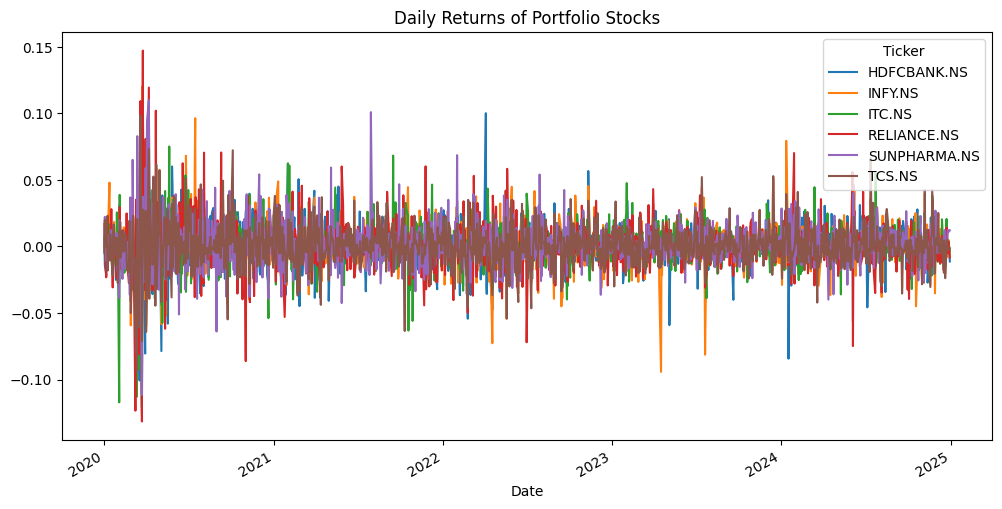

In [ ]:
returns.plot(figsize=(12,6))
plt.title("Daily Returns of Portfolio Stocks")
plt.show()

## Volatility Calculation

In this step, the volatility of each stock in the portfolio is calculated using the standard deviation of daily returns.

Volatility measures how much the price of a stock fluctuates over time. Higher volatility indicates higher uncertainty and risk, while lower volatility suggests more stable price movement.

This volatility measure is later used to estimate individual stock risk levels and contributes to the overall portfolio risk score.

In [ ]:
volatility = returns.std()

volatility

,0
Ticker,
HDFCBANK.NS,0.017181
INFY.NS,0.017550
ITC.NS,0.016300
RELIANCE.NS,0.018736
SUNPHARMA.NS,0.016121
TCS.NS,0.015414


## Stock Risk Level Classification

In this step, each stock is classified into risk categories based on its volatility value.

Volatility thresholds are used to group stocks into three levels:

- Low Risk → Stable price movement with smaller fluctuations
- Medium Risk → Moderate price variability
- High Risk → Large price fluctuations indicating higher uncertainty

This classification helps investors quickly understand which stocks contribute more risk to the overall portfolio.

In [ ]:
risk_levels = {}

for stock in volatility.index:
    if volatility[stock] < 0.015:
        risk_levels[stock] = "Low Risk"
    elif volatility[stock] < 0.02:
        risk_levels[stock] = "Medium Risk"
    else:
        risk_levels[stock] = "High Risk"

risk_levels

{'HDFCBANK.NS': 'Medium Risk',
 'INFY.NS': 'Medium Risk',
 'ITC.NS': 'Medium Risk',
 'RELIANCE.NS': 'Medium Risk',
 'SUNPHARMA.NS': 'Medium Risk',
 'TCS.NS': 'Medium Risk'}

## Portfolio Volatility Calculation

This step calculates overall portfolio volatility using the standard deviation of average daily returns. It helps estimate total portfolio risk.

In [ ]:
portfolio_volatility = returns.mean(axis=1).std()

portfolio_volatility

0.011343464747330098

## Portfolio Risk Classification

This step classifies the portfolio as Low, Medium, or High Risk based on the calculated portfolio volatility.

In [ ]:
if portfolio_volatility < 0.012:
    portfolio_risk = "Low Risk Portfolio"
elif portfolio_volatility < 0.018:
    portfolio_risk = "Medium Risk Portfolio"
else:
    portfolio_risk = "High Risk Portfolio"

portfolio_risk

'Low Risk Portfolio'

## Correlation Analysis

This step calculates correlation between stocks to identify how similarly they move. High correlation indicates lower diversification.

In [ ]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Ticker,,,,,,
HDFCBANK.NS,1.000000,0.357681,0.290478,0.441828,0.264502,0.313961
INFY.NS,0.357681,1.000000,0.247935,0.361304,0.284388,0.707710
ITC.NS,0.290478,0.247935,1.000000,0.305166,0.295039,0.243443
RELIANCE.NS,0.441828,0.361304,0.305166,1.000000,0.317954,0.386882
SUNPHARMA.NS,0.264502,0.284388,0.295039,0.317954,1.000000,0.274966
TCS.NS,0.313961,0.707710,0.243443,0.386882,0.274966,1.000000


## Correlation Heatmap Visualization

This step visualizes the correlation matrix using a heatmap to clearly identify relationships between stocks in the portfolio.

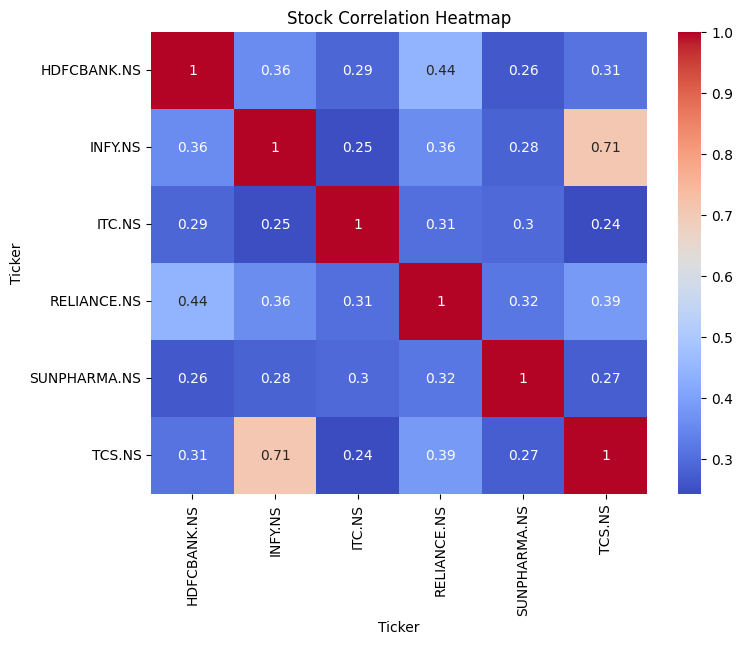

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Stock Correlation Heatmap")
plt.show()

## High Correlation Detection

This step identifies stock pairs with high correlation values above a selected threshold, indicating possible diversification risk.

In [ ]:
high_correlation_pairs = []

threshold = 0.7

for i in correlation_matrix.columns:
    for j in correlation_matrix.columns:
        if i != j and correlation_matrix.loc[i, j] > threshold:
            pair = tuple(sorted((i, j)))
            if pair not in high_correlation_pairs:
                high_correlation_pairs.append(pair)

high_correlation_pairs

[('INFY.NS', 'TCS.NS')]

## Diversification Warning

This step checks whether highly correlated stocks exist and displays a warning if diversification risk is detected.

In [ ]:
if high_correlation_pairs:
    print("Diversification Warning:")
    for pair in high_correlation_pairs:
        print(f"High correlation detected between {pair[0]} and {pair[1]}")
else:
    print("Portfolio is well diversified.")

Diversification Warning:
High correlation detected between INFY.NS and TCS.NS


## Single Stock Data Preparation

This step downloads historical price data for TCS stock, which will be used to train the machine learning model for trend prediction.

In [ ]:
tcs_data = yf.download("TCS.NS", start="2020-01-01", end="2024-12-31")

tcs_data.head()

/tmp/ipykernel_15171/4127019019.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs_data = yf.download("TCS.NS", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1866.114014,1880.146719,1854.405520,1866.458295,1354908
2020-01-02,1857.547607,1876.745997,1850.272939,1876.745997,2380752
2020-01-03,1894.566772,1913.808249,1863.014417,1863.014417,4655761
2020-01-06,1894.394409,1916.347673,1883.589918,1898.311602,3023209
2020-01-07,1899.043701,1906.619562,1880.060541,1894.437736,2429317


## Trend Feature Creation

This step creates the target variable for prediction.  
The next-day closing price is compared with the current closing price to label stock movement as UP (1) or DOWN (0).

In [ ]:

tcs_close_prices = tcs_data[('Close', 'TCS.NS')]

tcs_data["Next_Close"] = tcs_close_prices.shift(-1)

tcs_data["Trend"] = (tcs_data["Next_Close"] > tcs_close_prices).astype(int)

tcs_data.head()

Price,Close,High,Low,Open,Volume,Next_Close,Trend
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,
Date,,,,,,,
2020-01-01,1866.114014,1880.146719,1854.405520,1866.458295,1354908,1857.547607,0
2020-01-02,1857.547607,1876.745997,1850.272939,1876.745997,2380752,1894.566772,1
2020-01-03,1894.566772,1913.808249,1863.014417,1863.014417,4655761,1894.394409,0
2020-01-06,1894.394409,1916.347673,1883.589918,1898.311602,3023209,1899.043701,1
2020-01-07,1899.043701,1906.619562,1880.060541,1894.437736,2429317,1941.572998,1


## Feature Selection for Model Training

This step selects important stock price indicators as input features and defines the target variable (Trend) for training the prediction model.

In [ ]:
features = ["Open", "High", "Low", "Close", "Volume"]

X = tcs_data[features]

y = tcs_data["Trend"]

## Removing Missing Values

This step removes the last row containing missing values created during target variable shifting to ensure clean data for model training.

In [ ]:
X = X[:-1]
y = y[:-1]

## Train-Test Data Split

This step divides the dataset into training and testing sets.  
The training data is used to build the model, while the testing data evaluates prediction performance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

## Model Training Using Random Forest

This step trains the Random Forest classification model using the training dataset to predict the next-day stock trend.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

## Model Accuracy Evaluation

This step evaluates the performance of the trained model by calculating prediction accuracy on the testing dataset.

In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

accuracy

0.5282258064516129

## Next-Day Trend Prediction

This step uses the trained model to predict the next-day stock movement as either UP or DOWN based on the latest available data.

In [ ]:
latest_data = X.tail(1)

prediction = model.predict(latest_data)

if prediction[0] == 1:
    print("Predicted Trend: UP ")
else:
    print("Predicted Trend: DOWN ")

Predicted Trend: DOWN 


## Prediction Confidence Score

This step calculates the confidence level of the predicted trend using probability values generated by the trained model.

In [ ]:
prediction_prob = model.predict_proba(latest_data)

confidence = round(max(prediction_prob[0]) * 100, 2)

confidence

np.float64(65.0)

## Trend Prediction with Confidence Level

This step displays the predicted stock trend along with the confidence percentage generated by the model.

In [ ]:
if prediction[0] == 1:
    print(f"Predicted Trend: UP with confidence {confidence}%")
else:
    print(f"Predicted Trend: DOWN with confidence {confidence}%")

Predicted Trend: DOWN with confidence 65.0%


## Signal Strength Classification

This step classifies the prediction confidence into Strong, Moderate, or Weak signal levels to interpret the reliability of the forecast.

In [ ]:
if confidence >= 75:
    signal_strength = "Strong Signal"
elif confidence >= 60:
    signal_strength = "Moderate Signal"
else:
    signal_strength = "Weak Signal"

signal_strength

'Moderate Signal'

## Stock Trend Prediction Report

This step displays the final predicted trend along with its confidence level and signal strength for better interpretation of model results.

In [ ]:
print("Stock Trend Prediction Report")
print("-----------------------------")

if prediction[0] == 1:
    print("Trend: UP")
else:
    print("Trend: DOWN")

print(f"Confidence Level: {confidence}%")
print(f"Signal Strength: {signal_strength}")

Stock Trend Prediction Report
-----------------------------
Trend: DOWN
Confidence Level: 65.0%
Signal Strength: Moderate Signal


## Portfolio Recommendation Generation

This step generates investment suggestions based on portfolio volatility and correlation risk to improve diversification and stability.

In [ ]:
recommendations = []

if high_correlation_pairs:
    recommendations.append("Reduce exposure to highly correlated stocks.")

if portfolio_volatility > 0.018:
    recommendations.append("Portfolio volatility is high. Consider adding stable stocks like FMCG.")

if portfolio_volatility < 0.012:
    recommendations.append("Portfolio risk is low. You may consider adding growth-sector stocks.")

if not recommendations:
    recommendations.append("Portfolio structure looks balanced.")

recommendations

['Reduce exposure to highly correlated stocks.',
 'Portfolio risk is low. You may consider adding growth-sector stocks.']

## Portfolio Intelligence Report

This step summarizes prediction results, portfolio risk level, diversification status, and investment recommendations into a single consolidated report.

In [ ]:
print("PORTFOLIO INTELLIGENCE REPORT")
print("--------------------------------------------------")

# Trend prediction
if prediction[0] == 1:
    print("Predicted Trend: UP ")
else:
    print("Predicted Trend: DOWN ")

print(f"Confidence Level: {confidence}%")
print(f"Signal Strength: {signal_strength}")

print("\nPortfolio Risk Level:")
print(portfolio_risk)

print("\nDiversification Analysis:")

if high_correlation_pairs:
    for pair in high_correlation_pairs:
        print(f"High correlation detected between {pair[0]} and {pair[1]}")
else:
    print("Portfolio is well diversified.")

print("\nRecommendations:")

for rec in recommendations:
    print("-", rec)

PORTFOLIO INTELLIGENCE REPORT
--------------------------------------------------
Predicted Trend: DOWN 
Confidence Level: 65.0%
Signal Strength: Moderate Signal

Portfolio Risk Level:
Low Risk Portfolio

Diversification Analysis:
High correlation detected between INFY.NS and TCS.NS

Recommendations:
- Reduce exposure to highly correlated stocks.
- Portfolio risk is low. You may consider adding growth-sector stocks.


## Multi-Stock Trend Prediction

This step applies the Random Forest model to multiple portfolio stocks to predict next-day trend direction and confidence level for each stock.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

multi_stock_results = {}

for stock in stocks:

    stock_data = yf.download(stock, start="2020-01-01", end="2024-12-31")

    # Flatten MultiIndex columns if they exist (common with yfinance single stock download)
    if isinstance(stock_data.columns, pd.MultiIndex):
        # Create new column names by joining levels, e.g., "Close_TCS.NS"
        stock_data.columns = ['_'.join(col).strip() for col in stock_data.columns.values]

    # Now "Close_STOCK_NAME" will be the column name for Close prices
    close_col_name = f"Close_{stock}"
    open_col_name = f"Open_{stock}"
    high_col_name = f"High_{stock}"
    low_col_name = f"Low_{stock}"
    volume_col_name = f"Volume_{stock}"

    stock_data["Next_Close"] = stock_data[close_col_name].shift(-1)
    stock_data["Trend"] = (stock_data["Next_Close"] > stock_data[close_col_name]).astype(int)

    features = [open_col_name, high_col_name, low_col_name, close_col_name, volume_col_name]

    X = stock_data[features][:-1]
    y = stock_data["Trend"][:-1]

    split = int(len(X)*0.8)

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]

    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)

    latest_data = X.tail(1)

    prediction = model.predict(latest_data)
    probability = model.predict_proba(latest_data)

    confidence = round(max(probability[0]) * 100, 2)

    multi_stock_results[stock] = (prediction[0], confidence)

multi_stock_results

/tmp/ipykernel_15171/304508471.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_15171/304508471.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_15171/304508471.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_15171/304508471.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start="2020-01-01", end="2024-12-31")
[*********************100%*******************

{'TCS.NS': (np.int64(0), np.float64(71.0)),
 'INFY.NS': (np.int64(0), np.float64(92.0)),
 'RELIANCE.NS': (np.int64(0), np.float64(55.0)),
 'HDFCBANK.NS': (np.int64(0), np.float64(71.0)),
 'ITC.NS': (np.int64(0), np.float64(95.0)),
 'SUNPHARMA.NS': (np.int64(0), np.float64(74.0))}

## Multi-Stock Prediction Report

This step displays the predicted trend and confidence level for each stock in the portfolio using the trained machine learning model.

In [ ]:
print("MULTI-STOCK TREND PREDICTION REPORT")
print("----------------------------------")

for stock, (pred, conf) in multi_stock_results.items():

    if pred == 1:
        trend = "UP"
    else:
        trend = "DOWN"

    print(f"{stock}: {trend} (Confidence: {conf}%)")

MULTI-STOCK TREND PREDICTION REPORT
----------------------------------
TCS.NS: DOWN (Confidence: 71.0%)
INFY.NS: DOWN (Confidence: 92.0%)
RELIANCE.NS: DOWN (Confidence: 55.0%)
HDFCBANK.NS: DOWN (Confidence: 71.0%)
ITC.NS: DOWN (Confidence: 95.0%)
SUNPHARMA.NS: DOWN (Confidence: 74.0%)


## Portfolio Trend Summary

This step evaluates the overall portfolio direction by comparing predicted trends of all selected stocks to determine whether the portfolio shows upward, downward, or neutral movement.

In [ ]:
up_count = sum(1 for pred, conf in multi_stock_results.values() if pred == 1)
down_count = len(multi_stock_results) - up_count

if up_count > down_count:
    portfolio_trend = "Portfolio shows upward momentum"
elif down_count > up_count:
    portfolio_trend = "Portfolio shows downward pressure"
else:
    portfolio_trend = "Portfolio trend is neutral ⚖️"

portfolio_trend

'Portfolio shows downward pressure'

## Sector Mapping of Stocks

This step assigns each stock to its respective market sector to support sector concentration and diversification analysis.

In [ ]:
sector_map = {
    "TCS.NS": "IT",
    "INFY.NS": "IT",
    "RELIANCE.NS": "Energy",
    "HDFCBANK.NS": "Banking",
    "ITC.NS": "FMCG",
    "SUNPHARMA.NS": "Pharma"
}

sector_map

{'TCS.NS': 'IT',
 'INFY.NS': 'IT',
 'RELIANCE.NS': 'Energy',
 'HDFCBANK.NS': 'Banking',
 'ITC.NS': 'FMCG',
 'SUNPHARMA.NS': 'Pharma'}

## Sector Distribution Analysis

This step counts the number of stocks in each sector to evaluate sector concentration within the portfolio.

In [ ]:
from collections import Counter

sector_counts = Counter(sector_map.values())

sector_counts

Counter({'IT': 2, 'Energy': 1, 'Banking': 1, 'FMCG': 1, 'Pharma': 1})

## Diversification Score Calculation

This step calculates the diversification score based on sector distribution to measure how balanced the portfolio is across sectors.

In [ ]:
total_stocks = len(sector_map)

max_sector_weight = max(sector_counts.values()) / total_stocks

diversification_score = round((1 - max_sector_weight) * 100, 2)

diversification_score

66.67

## Diversification Status Classification

This step classifies the portfolio as well diversified, moderately diversified, or poorly diversified based on the calculated diversification score.

In [ ]:
if diversification_score >= 80:
    diversification_status = "Well Diversified"
elif diversification_score >= 50:
    diversification_status = "Moderately Diversified"
else:
    diversification_status = "Poorly Diversified"

diversification_status

'Moderately Diversified'

## Portfolio Diversification Report

This step displays the diversification score and overall diversification status of the portfolio.

In [ ]:
print("PORTFOLIO DIVERSIFICATION REPORT")
print("--------------------------------")
print(f"Diversification Score: {diversification_score}/100")
print(f"Status: {diversification_status}")

PORTFOLIO DIVERSIFICATION REPORT
--------------------------------
Diversification Score: 66.67/100
Status: Moderately Diversified


## Sector Concentration Detection

This step identifies sectors with higher stock concentration than the threshold, indicating possible sector exposure risk in the portfolio.

In [ ]:
dominant_sectors = []

threshold = 0.2  # 40% concentration threshold

for sector, count in sector_counts.items():
    if count / total_stocks > threshold:
        dominant_sectors.append(sector)

dominant_sectors

['IT']

## Sector Replacement Suggestions

This step identifies alternative sectors to improve portfolio diversification when high sector concentration is detected.

In [ ]:
sector_alternatives = {
    "IT": ["Pharma", "FMCG", "Energy"],
    "Banking": ["IT", "FMCG"],
    "Energy": ["Banking", "Pharma"],
    "Pharma": ["IT", "Energy"],
    "FMCG": ["Banking", "Pharma"]
}

replacement_suggestions = []

for sector in dominant_sectors:
    if sector in sector_alternatives:
        replacement_suggestions.extend(sector_alternatives[sector])

replacement_suggestions

['Pharma', 'FMCG', 'Energy']

## Suggested Replacement Stocks

This step identifies example stocks from alternative sectors to improve portfolio diversification and reduce sector concentration risk.

In [ ]:
sector_stock_examples = {
    "IT": ["TCS.NS", "INFY.NS"],
    "Banking": ["HDFCBANK.NS"],
    "Energy": ["RELIANCE.NS"],
    "FMCG": ["ITC.NS"],
    "Pharma": ["SUNPHARMA.NS"]
}

suggested_stocks = []

for sector in replacement_suggestions:
    suggested_stocks.extend(sector_stock_examples.get(sector, []))

suggested_stocks

['SUNPHARMA.NS', 'ITC.NS', 'RELIANCE.NS']

## Portfolio Rebalancing Suggestions

This step provides sector-level and stock-level suggestions to improve portfolio balance when high sector concentration is detected.

In [ ]:
print("PORTFOLIO REBALANCING SUGGESTIONS")
print("----------------------------------")

if dominant_sectors:
    for sector in dominant_sectors:
        print(f"High exposure detected in {sector} sector.")

    print("\nSuggested sectors to add:")
    for sector in replacement_suggestions:
        print("-", sector)

    print("\nExample replacement stocks:")
    for stock in suggested_stocks:
        print("-", stock)

else:
    print("Portfolio sector allocation looks balanced.")

PORTFOLIO REBALANCING SUGGESTIONS
----------------------------------
High exposure detected in IT sector.

Suggested sectors to add:
- Pharma
- FMCG
- Energy

Example replacement stocks:
- SUNPHARMA.NS
- ITC.NS
- RELIANCE.NS


## Correlation-Based Sector Risk Detection

This step identifies highly correlated stocks within the same sector to detect hidden diversification risk in the portfolio.

In [ ]:
correlation_threshold = 0.7

sector_risk_pairs = []

for stock1 in correlation_matrix.columns:
    for stock2 in correlation_matrix.columns:

        if stock1 != stock2:

            corr_value = correlation_matrix.loc[stock1, stock2]

            if corr_value > correlation_threshold:

                sector1 = sector_map.get(stock1)
                sector2 = sector_map.get(stock2)

                if sector1 == sector2:

                    pair = tuple(sorted((stock1, stock2)))

                    if pair not in sector_risk_pairs:
                        sector_risk_pairs.append(pair)

sector_risk_pairs

[('INFY.NS', 'TCS.NS')]

## Sector-Level Correlation Risk Identification

This step identifies sectors that contain highly correlated stocks, indicating potential diversification risk within the portfolio.

In [ ]:
correlation_risk_sectors = set()

for stock1, stock2 in sector_risk_pairs:
    correlation_risk_sectors.add(sector_map[stock1])

correlation_risk_sectors

{'IT'}

## Correlation-Based Sector Suggestions

This step identifies alternative sectors to reduce risk when highly correlated stocks are detected within the same sector.

In [ ]:
correlation_replacement_suggestions = []

for sector in correlation_risk_sectors:
    if sector in sector_alternatives:
        correlation_replacement_suggestions.extend(
            sector_alternatives[sector]
        )

correlation_replacement_suggestions

['Pharma', 'FMCG', 'Energy']

## Correlation-Based Diversification Report

This step summarizes highly correlated stock pairs, identifies affected sectors, and suggests alternative sectors to improve diversification.

In [ ]:
print("CORRELATION-BASED DIVERSIFICATION REPORT")
print("----------------------------------------")

if sector_risk_pairs:

    print("Highly correlated stocks detected:")

    for pair in sector_risk_pairs:
        print("-", pair[0], "&", pair[1])

    print("\nRisk sectors identified:")

    for sector in correlation_risk_sectors:
        print("-", sector)

    print("\nSuggested sectors to diversify into:")

    for sector in correlation_replacement_suggestions:
        print("-", sector)

else:
    print("No high correlation sector risk detected.")

CORRELATION-BASED DIVERSIFICATION REPORT
----------------------------------------
Highly correlated stocks detected:
- INFY.NS & TCS.NS

Risk sectors identified:
- IT

Suggested sectors to diversify into:
- Pharma
- FMCG
- Energy


## Volatility Risk Score Calculation

This step converts portfolio volatility into a normalized risk score contribution used in the overall portfolio risk evaluation.

In [ ]:
volatility_score = min(portfolio_volatility * 4000, 40)
volatility_score

40

## Correlation Risk Score Calculation

This step calculates a correlation-based risk score contribution depending on the number of highly correlated stock pairs in the portfolio.

In [ ]:
correlation_score = len(sector_risk_pairs) * 10

correlation_score = min(correlation_score, 30)

correlation_score

10

## Sector Concentration Risk Score

This step calculates the sector concentration risk contribution based on the number of dominant sectors in the portfolio.

In [ ]:
sector_concentration_score = len(dominant_sectors) * 30

sector_concentration_score = min(sector_concentration_score, 30)

sector_concentration_score

30

## Final Portfolio Risk Score

This step calculates the overall portfolio risk score by combining volatility, correlation risk, and sector concentration risk contributions.

In [ ]:
portfolio_risk_score = round(
    volatility_score +
    correlation_score +
    sector_concentration_score,
    2
)

portfolio_risk_score

80

## Portfolio Risk Level Classification

This step categorizes the portfolio into Low, Moderate, or High Risk based on the calculated portfolio risk score.

In [ ]:
if portfolio_risk_score >= 70:
    final_risk_level = "High Risk Portfolio"
elif portfolio_risk_score >= 40:
    final_risk_level = "Moderate Risk Portfolio"
else:
    final_risk_level = "Low Risk Portfolio"

final_risk_level

'High Risk Portfolio'

## Final Portfolio Risk Dashboard

This step displays the overall portfolio risk score along with individual contributions from volatility, correlation, and sector concentration factors.

In [ ]:
print("FINAL PORTFOLIO RISK DASHBOARD")
print("--------------------------------")

print(f"Portfolio Risk Score: {portfolio_risk_score} / 100")
print(f"Risk Category: {final_risk_level}")

print("\nRisk Contributors:")

print(f"- Volatility Contribution: {round(volatility_score,2)}")
print(f"- Correlation Contribution: {correlation_score}")
print(f"- Sector Concentration Contribution: {sector_concentration_score}")

FINAL PORTFOLIO RISK DASHBOARD
--------------------------------
Portfolio Risk Score: 80 / 100
Risk Category: High Risk Portfolio

Risk Contributors:
- Volatility Contribution: 40
- Correlation Contribution: 10
- Sector Concentration Contribution: 30


## Portfolio Trend Count Analysis

This step counts how many stocks show upward and downward predicted trends to support overall portfolio decision-making.

In [ ]:
up_count = sum(1 for pred, conf in multi_stock_results.values() if pred == 1)
down_count = len(multi_stock_results) - up_count

up_count, down_count

(0, 6)

## Portfolio Trend Signal Classification

This step determines whether the overall portfolio trend is Bullish, Bearish, or Neutral based on the predicted trends of all stocks.

In [ ]:
if up_count > down_count:
    portfolio_signal = "Bullish"
elif down_count > up_count:
    portfolio_signal = "Bearish"
else:
    portfolio_signal = "Neutral"

portfolio_signal

'Bearish'

## Final Investment Decision Logic

This step determines the final investment action such as Invest More, Hold, Rebalance Portfolio, or Reduce Exposure based on portfolio risk score and trend signal.

In [ ]:
if portfolio_risk_score >= 70:
    final_decision = "REDUCE EXPOSURE"

elif portfolio_signal == "Bullish" and portfolio_risk_score < 50:
    final_decision = "INVEST MORE"

elif portfolio_signal == "Neutral":
    final_decision = "HOLD"

else:
    final_decision = "REBALANCE PORTFOLIO"

final_decision

'REDUCE EXPOSURE'

## Decision Reason Identification

This step lists the key factors influencing the final investment decision based on risk score, correlation risk, sector concentration, and portfolio trend signal.

In [ ]:
decision_reasons = []

if portfolio_risk_score >= 70:
    decision_reasons.append("Portfolio risk score is high")

if correlation_score > 0:
    decision_reasons.append("Highly correlated stocks detected")

if dominant_sectors:
    decision_reasons.append("Sector concentration detected")

if portfolio_signal == "Bullish":
    decision_reasons.append("Majority stocks show upward trend")

if portfolio_signal == "Bearish":
    decision_reasons.append("Majority stocks show downward trend")

decision_reasons

['Portfolio risk score is high',
 'Highly correlated stocks detected',
 'Sector concentration detected',
 'Majority stocks show downward trend']

## Final Portfolio Intelligence Dashboard

This step presents a summary dashboard showing portfolio trend signal, risk score, diversification status, sector risks, and final investment recommendations.

In [ ]:
dashboard = {
    "Portfolio Trend Signal": portfolio_signal,
    "Portfolio Risk Score": f"{portfolio_risk_score} / 100",
    "Risk Category": final_risk_level,
    "Diversification Status": diversification_status,
    "Final Investment Decision": final_decision
}

print("\nFINAL PORTFOLIO\n")

for key, value in dashboard.items():
    print(f"{key:35} : {value}")

print("\nCorrelation Risk Stocks:")

if sector_risk_pairs:
    for pair in sector_risk_pairs:
        print("•", pair[0], "&", pair[1])
else:
    print("• None detected")

print("\nSector Concentration:")

if dominant_sectors:
    for sector in dominant_sectors:
        print("•", sector)
else:
    print("• Balanced allocation")

print("\nRecommended Actions:")

for rec in recommendations:
    print("•", rec)


FINAL PORTFOLIO

Portfolio Trend Signal              : Bearish
Portfolio Risk Score                : 80 / 100
Risk Category                       : High Risk Portfolio
Diversification Status              : Moderately Diversified
Final Investment Decision           : REDUCE EXPOSURE

Correlation Risk Stocks:
• INFY.NS & TCS.NS

Sector Concentration:
• IT

Recommended Actions:
• Reduce exposure to highly correlated stocks.
• Portfolio risk is low. You may consider adding growth-sector stocks.
